In [2]:
# 1. 라이브러리 불러오기
import numpy as np                                          # 넘파이
import pandas as pd                                         # 판다스
import matplotlib.pyplot as plt                             # 맷플롯립
import seaborn as sns                                       # 시본
from sklearn.model_selection import train_test_split        # 훈련, 테스트 데이터 분리
from sklearn.linear_model import LinearRegression           # 다중 선형 회귀
from sklearn.metrics import mean_squared_error, r2_score    # 다중 선형 회귀 모델 함수들
from sklearn.ensemble import RandomForestRegressor          # 랜덤 포레스트
import pickle
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
'''
사이킷런 라이브러리들 불러오기
'''

'\n사이킷런 라이브러리들 불러오기\n'

In [3]:
'''
# 에러 주의
.read_csv 메서드를 사용할 때 경로를 `따옴표`로 감쌀 것!!!
'''
# 2. 데이터 불러오기 (Sleep_Efficiency.csv)
sleep_csv = pd.read_csv('dataset/Sleep_Efficiency.csv')

In [4]:
# 3. 데이터 확인 (상위 5개 행, 컬럼 목록, 결측치 확인)
# 3-1. 상위 5개 행
sleep_csv.head()

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,10,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,24,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,28,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


In [5]:
# 3. 데이터 확인 (상위 5개 행, 컬럼 목록, 결측치 확인)
# 3-2. 컬럼 목록
sleep_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    object 
 3   Bedtime                 452 non-null    object 
 4   Wakeup time             452 non-null    object 
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     436 non-null    float64
 13  Smoking status          452 non-null    object 
 14  Exercise frequency      446 non-null    fl

In [6]:
# 3. 데이터 확인 (상위 5개 행, 컬럼 목록, 결측치 확인)
# 3-3. 결측치 확인
sleep_csv.isna().sum()

ID                         0
Age                        0
Gender                     0
Bedtime                    0
Wakeup time                0
Sleep duration             0
Sleep efficiency           0
REM sleep percentage       0
Deep sleep percentage      0
Light sleep percentage     0
Awakenings                20
Caffeine consumption      25
Alcohol consumption       16
Smoking status             0
Exercise frequency         6
dtype: int64

In [7]:
# 4. 필요한 컬럼만 추출
# (Age, Sleep duration, Caffeine consumption, Awakenings, Exercise frequency, Sleep efficiency)
df = sleep_csv[[ 'Age' 
                ,'Sleep duration' 
                ,'Caffeine consumption'
                ,'Awakenings'
                ,'Exercise frequency' 
                ,'Sleep efficiency']]
# 추출한 컬럼 상위 5개 데이터만 확인
df.head()

,Age,Sleep duration,Caffeine consumption,Awakenings,Exercise frequency,Sleep efficiency
0,65,6.0,0.0,0.0,3.0,0.88
1,69,7.0,0.0,3.0,3.0,0.66
2,40,8.0,0.0,1.0,3.0,0.89
3,40,6.0,50.0,3.0,1.0,0.51
4,57,8.0,0.0,3.0,3.0,0.76


In [8]:
# 5. 결측치 처리 (평균값으로 채우기)
df = df.fillna(df.mean())
# 상위 5개 데이터 확인
df.head()

,Age,Sleep duration,Caffeine consumption,Awakenings,Exercise frequency,Sleep efficiency
0,65,6.0,0.0,0.0,3.0,0.88
1,69,7.0,0.0,3.0,3.0,0.66
2,40,8.0,0.0,1.0,3.0,0.89
3,40,6.0,50.0,3.0,1.0,0.51
4,57,8.0,0.0,3.0,3.0,0.76


In [9]:
# 6. 종속변수 만들기
# (Sleep efficiency × 10 → Quality_of_Sleep)
df['Quality_of_Sleep'] = df['Sleep efficiency'] * 10 

# 상위 5개 데이터 확인
df.head()

,Age,Sleep duration,Caffeine consumption,Awakenings,Exercise frequency,Sleep efficiency,Quality_of_Sleep
0,65,6.0,0.0,0.0,3.0,0.88,8.8
1,69,7.0,0.0,3.0,3.0,0.66,6.6
2,40,8.0,0.0,1.0,3.0,0.89,8.9
3,40,6.0,50.0,3.0,1.0,0.51,5.1
4,57,8.0,0.0,3.0,3.0,0.76,7.6


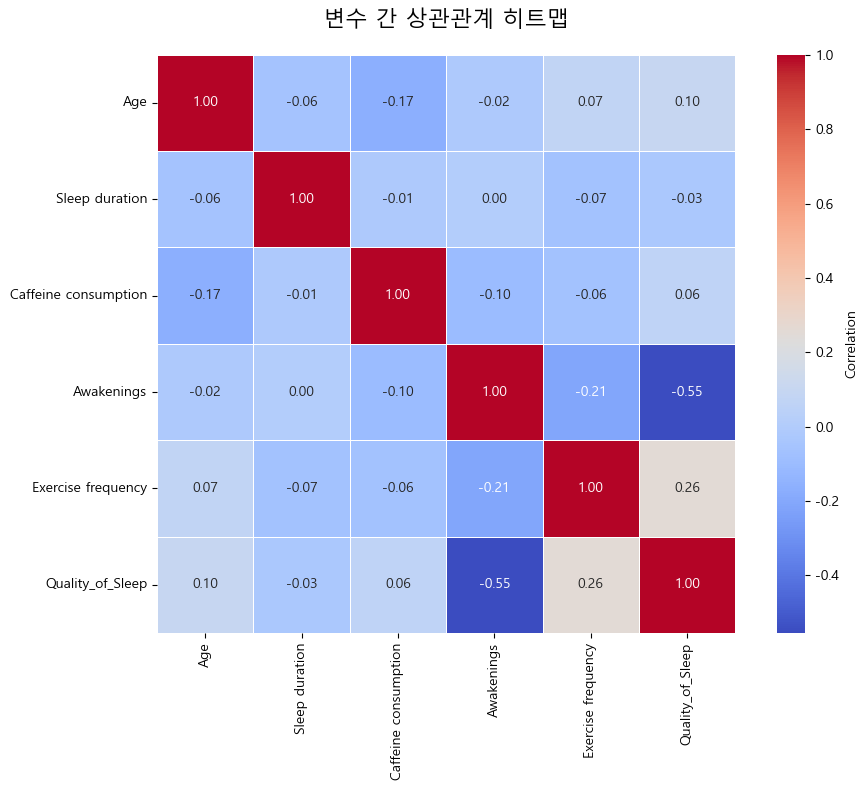

In [11]:
# 7. 상관관계 히트맵 (Sleep efficiency 제외)
# Sleep efficiency는 Quality_of_Sleep과 동일한 값(×10)이므로 제외

# 히트맵용 데이터프레임: 독립변수 5개 + 종속변수 1개만
heatmap_df = df[['Age', 'Sleep duration', 'Caffeine consumption', 
                 'Awakenings', 'Exercise frequency', 'Quality_of_Sleep']]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df.corr(), 
            annot=True,           # 숫자 표시
            fmt='.2f',            # 소수점 둘째자리
            cmap='coolwarm',      # 색상
            square=True,          # 정사각형
            linewidths=0.5,       # 격자 선
            cbar_kws={'label': 'Correlation'})
plt.title('변수 간 상관관계 히트맵', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 7. 독립변수(X)와 종속변수(y) 분리
X = df.iloc[:, : -2]  # 독립변수   
                      # [☆ 매우 중요 ☆] df 컬럼에 Sleep efficiency 컬럼은 Quality_of_Sleep와 동일한 값을 가지기에
                      #                 독립변수에 포함시키면 안됨!!
y = df.iloc[:, -1]    # 종속변수
                      # Quality_of_Sleep

In [12]:
# 7-1. 독립변수(X) 상위 5개 데이터 추출
X.head()

,Age,Sleep duration,Caffeine consumption,Awakenings,Exercise frequency
0,65,6.0,0.0,0.0,3.0
1,69,7.0,0.0,3.0,3.0
2,40,8.0,0.0,1.0,3.0
3,40,6.0,50.0,3.0,1.0
4,57,8.0,0.0,3.0,3.0


In [13]:
# 7-2. 종속변수(y) 상위 5개 데이터 추출
y.head()

0    8.8
1    6.6
2    8.9
3    5.1
4    7.6
Name: Quality_of_Sleep, dtype: float64

In [14]:
# 8. 학습 데이터 / 테스트 데이터 분할 (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# 8-1. 스케일러 적용
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# 9. 다중 선형 회귀 모델 학습
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# 10. 랜덤 포레스트 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
# 11. 두 모델 성능 비교 (R² 점수, RMSE)
# 예측값 생성
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# R² 점수
lr_r2 = r2_score(y_test, y_pred_lr)                               # y테스트 데이터, y 예측값 데이터
rf_r2 = r2_score(y_test, y_pred_rf)                               # y테스트 데이터, y 예측값 데이터

# RMSE
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))          # y테스트 데이터, y 예측값 데이터
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))          # y테스트 데이터, y 예측값 데이터

print(f"다중 선형 회귀 - R²: {lr_r2:.4f}, RMSE: {lr_rmse:.4f}")     # 현재 상황에서 다중 선형회귀가 랜덤포레스트보다 압도적으로 좋다.
print(f"랜덤 포레스트 - R²: {rf_r2:.4f}, RMSE: {rf_rmse:.4f}")

다중 선형 회귀 - R²: 0.3326, RMSE: 1.1147
랜덤 포레스트 - R²: 0.1990, RMSE: 1.2212


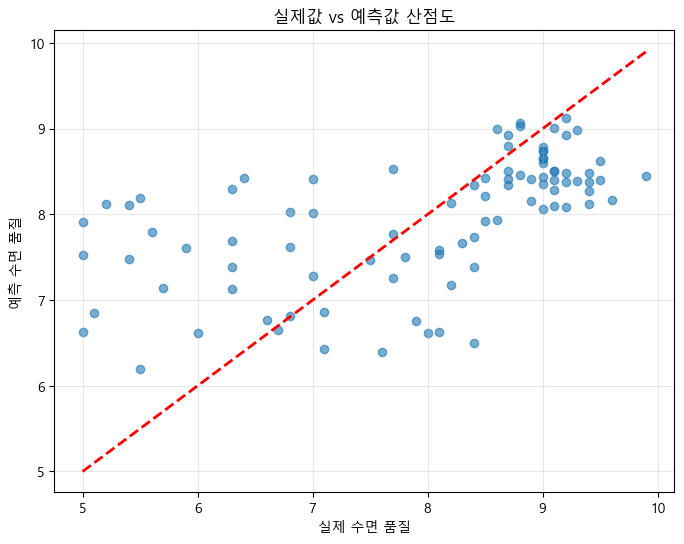

In [27]:
# 11-1. 실제값 vs 예측값 산점도 (다중 선형 회귀)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel('실제 수면 품질')
plt.ylabel('예측 수면 품질')
plt.title('실제값 vs 예측값 산점도')
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# 12. 더 좋은 모델 pkl 파일로 저장 (선형 회귀가 더 좋았으니까)
with open('model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

In [25]:
# 13. 스케일러도 pkl 파일로 저장
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)